# Dự đoán doanh thu xe hơi Huyndai dòng Elantra trong năm 2013 và đầu 2014


In [32]:
import pandas as pd
import numpy as np

df = pd.read_csv('elantra.csv')

In [33]:
df.tail()

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
45,11,2013,16751,7.0,231,242.301,234.033
46,12,2010,13096,9.4,170,227.190,220.437
47,12,2011,13025,8.5,253,243.015,227.093
48,12,2012,19024,7.9,275,244.698,231.099
49,12,2013,21692,6.7,279,246.189,234.594


In [34]:
df.sort_values(by=['Year', 'Month'], inplace=True)
df.reset_index(drop=True, inplace=True)

# sap xep theo nam va thang va reset index

In [35]:
df.tail()

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
45,10,2013,14876,7.2,223,243.374,233.782
46,11,2013,16751,7.0,231,242.301,234.033
47,12,2013,21692,6.7,279,246.189,234.594
48,1,2014,15326,6.6,232,247.575,234.933
49,2,2014,16393,6.7,240,246.389,235.169


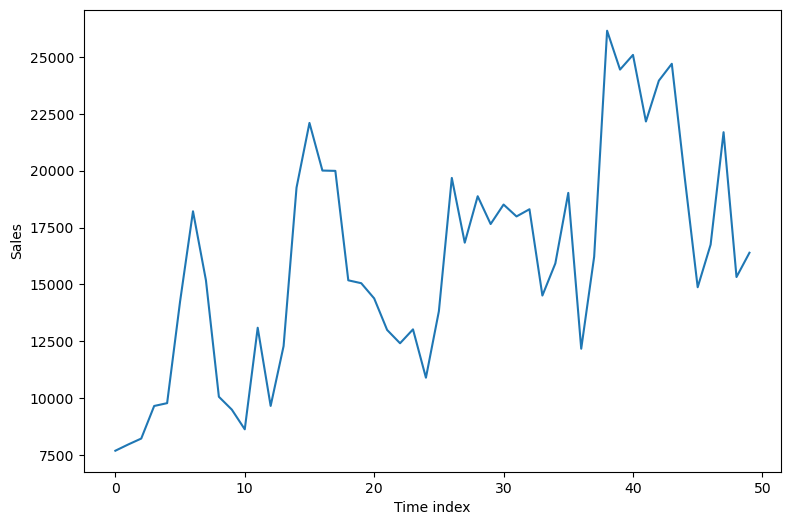

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))
plt.plot(df.ElantraSales.values)
plt.xlabel('Time index')
plt.ylabel('Sales')

plt.show()

In [37]:
numeric_feats = df.columns.drop(["ElantraSales", "Month", "Year"])
numeric_feats

Index(['Unemployment', 'Queries', 'CPI_energy', 'CPI_all'], dtype='object')

In [38]:
df_train = df[df.Year < 2013]
df_test = df[df.Year >= 2013]

y_train = df_train.ElantraSales.values
y_test = df_test.ElantraSales.values

### Feature scaling


In [39]:
# Chuan hoa du lieu bang StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(df_train[numeric_feats])

X_train = scaler.transform(df_train[numeric_feats])
X_test = scaler.transform(df_test[numeric_feats])

### Xây dựng Mô hình


In [40]:
# Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [41]:
y_pred = model.predict(X_test)
print(y_pred)

[15129.32450974 15944.28280393 17834.79849795 16486.45507841
 16519.78033285 17765.69837419 17429.42790606 17597.60236612
 18044.12407084 16520.88446216 17193.07580822 19043.20272132
 18419.26509553 18137.6000718 ]


In [42]:
from sklearn.metrics import mean_squared_error
def relative_error(y_true, y_pred):
    errors = np.abs(y_pred - y_true).astype(float) / y_true
    return np.mean(errors)*100

In [43]:
y_pred_test = model.predict(X_test)

print('RMSE: {:.2f}'.format(np.sqrt(mean_squared_error(y_test, y_pred_test))))
print('Mean relative errors: {:.1f}%'.format(relative_error(y_test, y_pred_test)))

RMSE: 5017.35
Mean relative errors: 19.0%


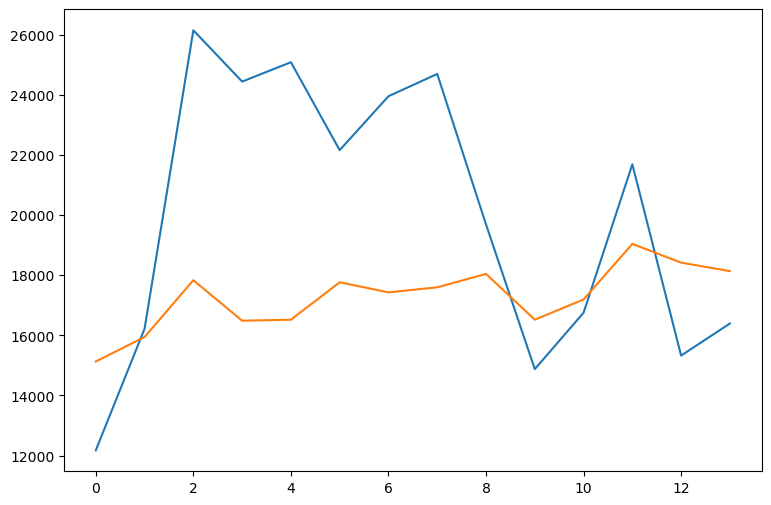

In [44]:
# Ve bieu do duong so sanh y_test va y_pred_test
plt.figure(figsize=(9, 6))
plt.plot(y_test, label='Actual Sales')
plt.plot(y_pred_test, label='Predicted Sales')

### Giải pháp cải tiến

In [45]:
# Bien moi thang thanh cac cong tac one-hot encoding
month_onehot_train = pd.get_dummies(df_train.Month)
month_onehot_train.head()



,1,2,3,4,5,6,7,8,9,10,11,12
0,True,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False


In [46]:
# Ghep dac trung Mont_1, Month_2, ..., Month_12 vao cac dac trung dang co, ket qua o dang numpy array
print(X_train.shape)
X_train = np.hstack([X_train, month_onehot_train.values])
print(X_train.shape)

(36, 4)
(36, 16)


In [47]:
# Tuong tu voi X_test
X_test = np.hstack((X_test, pd.get_dummies(df_test.Month)))

In [48]:
model.fit(X_train, y_train)

LinearRegression()

In [49]:
y_pred_test = model.predict(X_test)
print('RMSE: {:.2f}'.format(np.sqrt(mean_squared_error(y_test, y_pred_test))))
print('Mean relative errors: {:.1f}%'.format(relative_error(y_test, y_pred_test)))  

RMSE: 3590.37
Mean relative errors: 12.8%


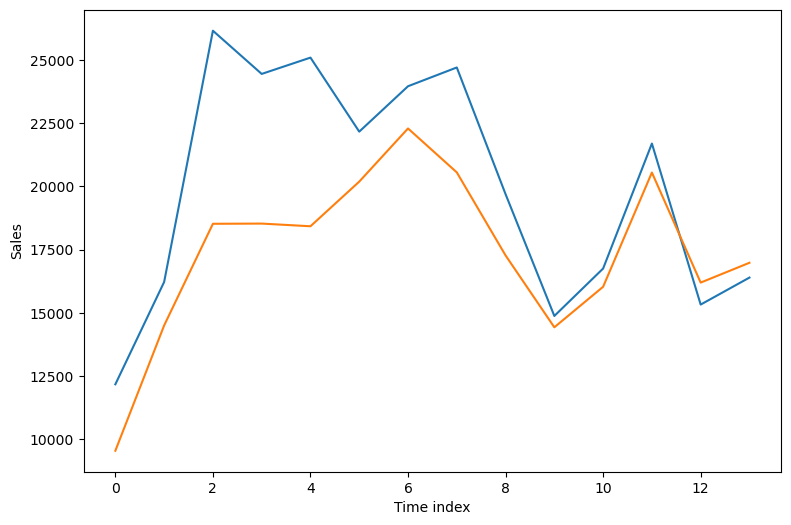

In [52]:
plt.figure(figsize=(9,6))
plt.plot(y_test)
plt.plot(y_pred_test)
plt.xlabel('Time index')
plt.ylabel('Sales')
# function to show the plot
plt.show()